The following code helps you to load and visualize the data (skeleton) in 3D xyz coordinates.
 

In [2]:
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
plt.style.use('seaborn-v0_8-poster')

#filename and folder to plot
fname= "walking_1"
folder = "/Users/ssscal/Downloads/amath_P2/train"

location_name=os.path.join(folder,fname+".npy")
vals = np.load(location_name)
xyz = np.reshape( vals[:,:], (38,3,-1) )


print(xyz.shape)

#define the root joint and scaling of the values
r = 1000
xroot, yroot, zroot = xyz[0,0,0], xyz[0,0,1], xyz[0,0,2]

#define the connections between the joints (skeleton) 
I = np.array(
        [1, 2, 3, 4, 5, 6, 1, 8, 9, 10, 11, 12, 1, 14, 15, 16, 17, 18, 19, 16, 21, 22, 23, 25, 26, 24, 28, 16, 30, 31,
         32, 33, 34, 35, 33, 37]) - 1
J = np.array(
        [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 26, 27, 28, 29, 30, 31, 32,
         33, 34, 35, 36, 37, 38]) - 1


(38, 3, 100)


In [3]:
# plot the skeleton accroding to joints (each plot is png image in anim folder)
os.makedirs("anim", exist_ok=True)
for tind in range(1,xyz.shape[2]):
    
    fig = plt.figure(figsize = (10,10))
    ax = plt.axes(projection='3d')
    for ijind in range(0,I.shape[0]):
        xline = np.array([xyz[I[ijind],0,tind], xyz[J[ijind],0,tind]])
        yline = np.array([xyz[I[ijind],1,tind], xyz[J[ijind],1,tind]])
        zline = np.array([xyz[I[ijind],2,tind], xyz[J[ijind],2,tind]])
        # use plot if you'd like to plot skeleton with lines
        ax.plot(xline,yline,zline)
    
    # use scatter if you'd like to plot all points without lines 
    # ax.scatter(xyz[:,0,tind],xyz[:,1,tind],xyz[:,2,tind], c = 'r', s = 50)   

    ax.set_xlim([-r+xroot, r+xroot])
    ax.set_zlim([-r+zroot, r+zroot])
    ax.set_ylim([-r+yroot, r+yroot])
    
    plt.savefig('anim/'+f"{tind}.png")
    plt.close()

# when plotting a single sample (the skeleton can simply be plotted without saving an image)
#     plt.draw()
#     plt.pause(.001)
#     plt.show()

 
    
# save the animated plot as a gif in anim folder 
from PIL import Image

images = [Image.open('anim/'+f"{n}.png") for n in range(1,xyz.shape[2])]
images[0].save('anim/'+fname+'.gif', save_all=True, append_images=images[1:], duration=30, loop=0) 

# remove ploted png images
for n in range(1,xyz.shape[2]):
    os.remove('anim/'+f"{n}.png")





## Tasks 1-5: PCA + classification
This section builds the PCA model, visualizes trajectories, and implements centroid-based classification.


In [33]:
import numpy as np
import os
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

plt.style.use('seaborn-v0_8-poster')

train_dir = '/Users/ssscal/Downloads/amath_P2/train'
test_dir = '/Users/ssscal/Downloads/amath_P2/test'

label_map = {'walking': 0, 'jumping': 1, 'running': 2}
label_names = {v: k for k, v in label_map.items()}

def load_samples(folder):
    files = sorted([f for f in os.listdir(folder) if f.endswith('.npy')])
    samples = []
    labels = []
    names = []
    for f in files:
        name = f.split('_')[0]
        arr = np.load(os.path.join(folder, f))
        samples.append(arr)
        labels.append(label_map[name])
        names.append(f)
    return samples, np.array(labels), names

train_samples, y_train, train_names = load_samples(train_dir)
test_samples, y_test, test_names = load_samples(test_dir)

print('train samples:', len(train_samples), 'test samples:', len(test_samples))
print('sample shape:', train_samples[0].shape)


train samples: 15 test samples: 3
sample shape: (114, 100)


k for energy thresholds: {0.7: 2, 0.8: 3, 0.9: 5, 0.95: 7}


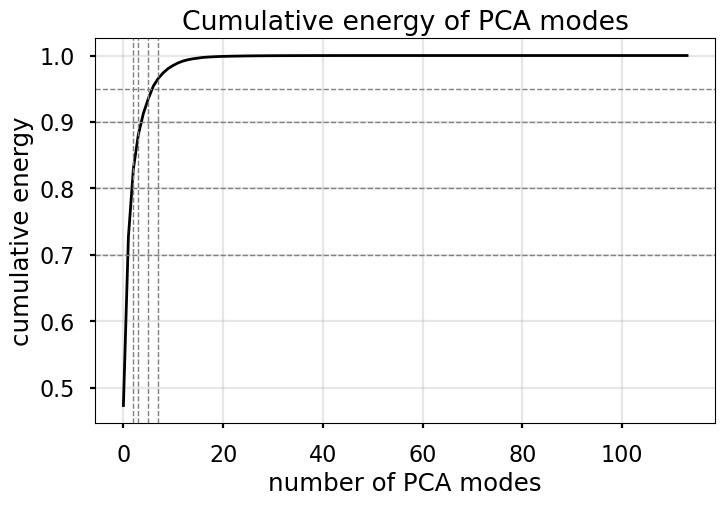

In [34]:
# Task 1: compile X_train and run PCA with spatial modes
# Each column is a 114-vector snapshot; concatenate all time snapshots across all samples
X_train = np.hstack(train_samples)  # shape (114, 100 * 15)

# PCA expects rows as samples, so transpose to (n_snapshots, n_features)
pca = PCA(n_components=114)
pca.fit(X_train.T)

cum_energy = np.cumsum(pca.explained_variance_ratio_)
thresholds = [0.70, 0.80, 0.90, 0.95]
k_for_threshold = {t: int(np.searchsorted(cum_energy, t) + 1) for t in thresholds}

print('k for energy thresholds:', k_for_threshold)

plt.figure(figsize=(8,5))
plt.plot(cum_energy, 'k-', lw=2)
for t in thresholds:
    k = k_for_threshold[t]
    plt.axhline(t, color='gray', linestyle='--', lw=1)
    plt.axvline(k, color='gray', linestyle='--', lw=1)
plt.xlabel('number of PCA modes')
plt.ylabel('cumulative energy')
plt.title('Cumulative energy of PCA modes')
plt.grid(True, alpha=0.3)
plt.show()


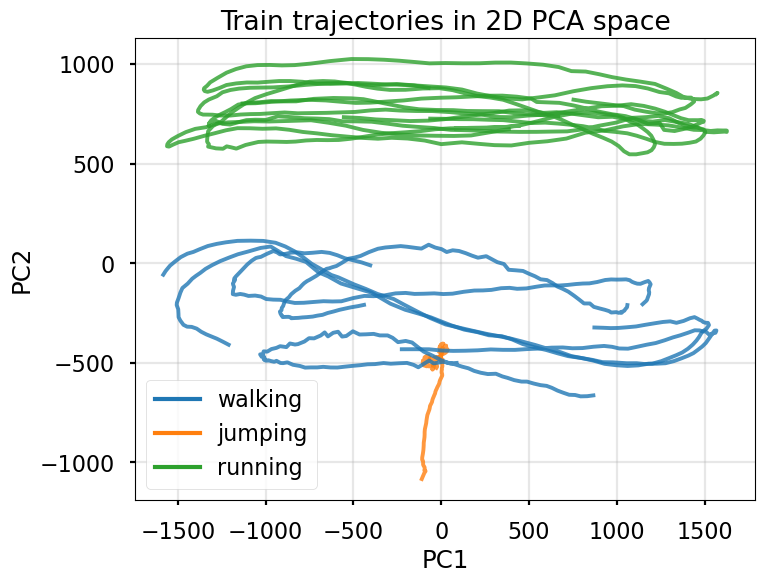

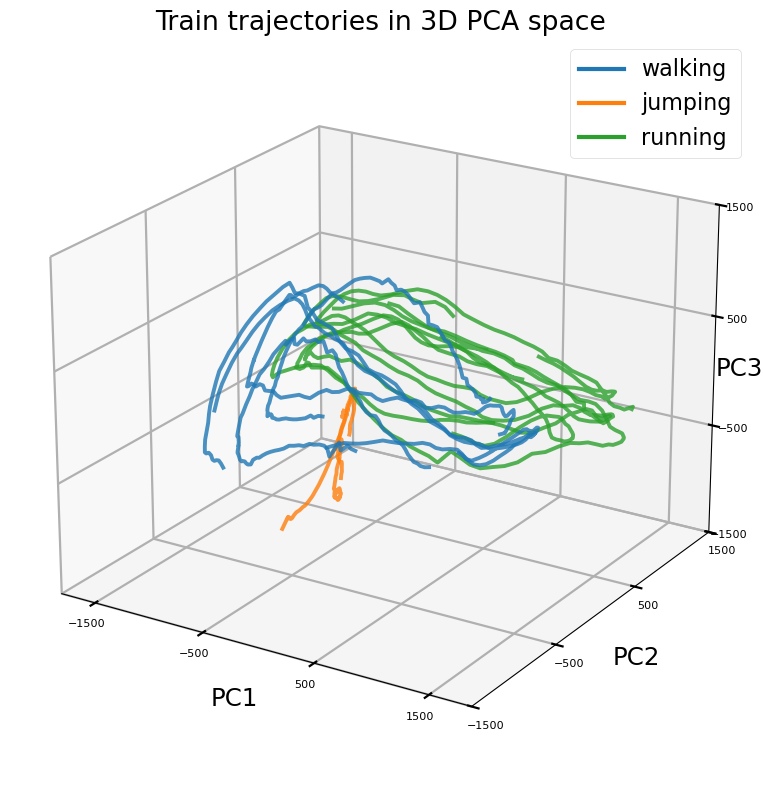

In [35]:
# Task 2: project onto 2D and 3D PCA space and plot trajectories
colors = {0: 'tab:blue', 1: 'tab:orange', 2: 'tab:green'}

def project_sample(sample, k):
    # sample: (114, 100) -> snapshots are columns
    proj = pca.transform(sample.T)[:, :k]  # (100, k)
    return proj

# 2D trajectories
plt.figure(figsize=(8,6))
for sample, lbl, name in zip(train_samples, y_train, train_names):
    traj = project_sample(sample, 2)
    plt.plot(traj[:,0], traj[:,1], color=colors[lbl], alpha=0.8)

handles = [plt.Line2D([0],[0], color=colors[i], lw=3) for i in range(3)]
plt.legend(handles, [label_names[i] for i in range(3)])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Train trajectories in 2D PCA space')
plt.grid(True, alpha=0.3)
plt.show()

# 3D trajectories
fig = plt.figure(figsize=(10,8))
fig.subplots_adjust(left=0.05, right=0.95, bottom=0.08, top=0.92)
ax = fig.add_subplot(111, projection='3d')
for sample, lbl in zip(train_samples, y_train):
    traj = project_sample(sample, 3)
    ax.plot(traj[:,0], traj[:,1], traj[:,2], color=colors[lbl], alpha=0.8)

handles3d = [plt.Line2D([0],[0], color=colors[i], lw=3) for i in range(3)]
ax.legend(handles3d, [label_names[i] for i in range(3)], loc='upper right')

ax.set_xlabel('PC1', labelpad=6)
ax.set_ylabel('PC2', labelpad=6)
ax.set_zlabel('PC3', labelpad=-10)
tick_vals = np.array([-1500, -500, 500, 1500])
ax.set_xticks(tick_vals)
ax.set_yticks(tick_vals)
ax.set_zticks(tick_vals)
ax.tick_params(axis='both', which='major', labelsize=8, pad=1)
ax.zaxis.set_tick_params(labelsize=8, pad=1)
ax.view_init(elev=22, azim=-58)
ax.set_title('Train trajectories in 3D PCA space')
plt.tight_layout()
plt.show()


In [36]:
# Task 3: ground truth labels and centroids in k-PCA space (snapshot-level)

def sample_snapshots(sample, k):
    # sample: (114, T) -> return (T, k) PCA coordinates for all snapshots
    return project_sample(sample, k)

def compute_centroids(samples, labels, k):
    centroids = {}
    for lbl in np.unique(labels):
        class_snaps = [sample_snapshots(s, k) for s, l in zip(samples, labels) if l == lbl]
        pts = np.vstack(class_snaps)
        centroids[lbl] = pts.mean(axis=0)
    return centroids

k_demo = 3
centroids_demo = compute_centroids(train_samples, y_train, k_demo)
print('centroids (k=3, snapshot-level):', centroids_demo)


centroids (k=3, snapshot-level): {np.int64(0): array([ -36.88211143, -253.35282541,  175.91202104]), np.int64(1): array([ -23.88986635, -499.36826149,  -72.5000755 ]), np.int64(2): array([  60.77197779,  752.7210869 , -103.41194553])}


training snapshot-level accuracy by k:
1 0.5073333333333333
2 0.8813333333333333
3 0.756
4 0.73
5 0.7506666666666667
6 0.726
7 0.8706666666666667
8 0.8753333333333333
9 0.8786666666666667
10 0.888
11 0.908
12 0.9093333333333333
13 0.91
14 0.9106666666666666
15 0.9106666666666666
16 0.9106666666666666


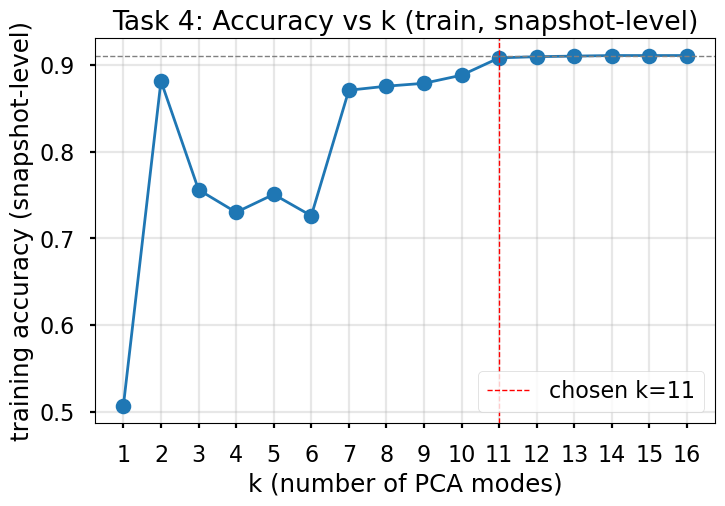

Chosen k (elbow rule): 11, accuracy=0.908


In [40]:
# Task 4: centroid classifier on training data for various k (snapshot-level)

def expand_snapshot_labels(samples, labels):
    y = []
    for s, lbl in zip(samples, labels):
        y.extend([lbl] * s.shape[1])
    return np.array(y)

def predict_snapshot_labels(samples, centroids, k):
    y_pred = []
    centroid_labels = np.array(sorted(centroids.keys()))
    centroid_mat = np.vstack([centroids[lbl] for lbl in centroid_labels])

    for s in samples:
        pts = sample_snapshots(s, k)
        dists = np.linalg.norm(pts[:, None, :] - centroid_mat[None, :, :], axis=2)
        pred_idx = np.argmin(dists, axis=1)
        y_pred.extend(centroid_labels[pred_idx].tolist())
    return np.array(y_pred)

k_vals = list(range(1, 17))
y_train_snap = expand_snapshot_labels(train_samples, y_train)
train_acc = {}
for k in k_vals:
    centroids = compute_centroids(train_samples, y_train, k)
    y_pred = predict_snapshot_labels(train_samples, centroids, k)
    train_acc[k] = accuracy_score(y_train_snap, y_pred)

print('training snapshot-level accuracy by k:')
for k in k_vals:
    print(k, train_acc[k])

acc_vals = [train_acc[k] for k in k_vals]
best_acc = max(acc_vals)
chosen_k = 11  # chosen elbow point

plt.figure(figsize=(8,5))
plt.plot(k_vals, acc_vals, marker='o', lw=2)
plt.axvline(chosen_k, color='red', linestyle='--', lw=1, label=f'chosen k={chosen_k}')
plt.axhline(best_acc, color='gray', linestyle='--', lw=1)
plt.xlabel('k (number of PCA modes)')
plt.ylabel('training accuracy (snapshot-level)')
plt.title('Task 4: Accuracy vs k (train, snapshot-level)')
plt.xticks(k_vals)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'Chosen k (elbow rule): {chosen_k}, accuracy={train_acc[chosen_k]:.3f}')


If instead the question is about how to generally choose the reduced dimension k, then the answer depends on the needs of the problem. Often, one imposes a criterion such as retaining at least 70% or 80% of the total information (energy) in the reduced dimensions. There are also common heuristics based on visually inspecting the singular value (or energy) plot and selecting k at the inflection point (the “elbow”), where the explained energy curve starts to level off.

In [38]:
# Task 5: test accuracy using the trained centroids (snapshot-level)

test_acc = {}
y_test_snap = expand_snapshot_labels(test_samples, y_test)
for k in k_vals:
    centroids = compute_centroids(train_samples, y_train, k)
    y_pred_test = predict_snapshot_labels(test_samples, centroids, k)
    test_acc[k] = accuracy_score(y_test_snap, y_pred_test)

print('test snapshot-level accuracy by k:')
for k in k_vals:
    print(k, test_acc[k])


test snapshot-level accuracy by k:
1 0.4866666666666667
2 0.9833333333333333
3 0.9233333333333333
4 0.7466666666666667
5 0.9166666666666666
6 0.7166666666666667
7 0.9433333333333334
8 0.93
9 0.9433333333333334
10 0.9433333333333334
11 0.9533333333333334
12 0.9533333333333334
13 0.9533333333333334
14 0.9533333333333334
15 0.9533333333333334
16 0.9533333333333334
